# Phase 2: ESN vs QRC Failure Analysis

The current best QRC regression result improves over earlier QRC variants but remains far behind the classical ESN baseline. This notebook asks why.

It compares a self-contained ESN against the current best QRC reservoir/readout on the same PCA-6 rolling-window data and same target.

Diagnostics:

- RMSE / QLIKE / Mincer-Zarnowitz R²;
- prediction mean/std/correlation by split;
- high-volatility recall;
- error by actual-volatility quantile;
- ESN state diagnostics vs QRC feature diagnostics.

Goal: identify whether ESN wins because of carryover/memory, higher state dimension, better high-vol activation, or simply better readout calibration.

In [1]:
from pathlib import Path
import os

if Path.cwd().name == "notebooks":
    os.chdir("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

from qpitome_qrc.data.features import FEATURE_COLUMNS
from qpitome_qrc.data.loaders import load_phase2_volatility_data
from qpitome_qrc.data.pca import fit_transform_pca_splits_train_only
from qpitome_qrc.data.splits import chronological_tabular_split
from qpitome_qrc.evaluation.metrics import evaluate_volatility_forecast
from qpitome_qrc.qrc.tfim_reservoir import (
    TFIMQRCConfig,
    _safe_feature_target_correlations,
    diagnose_reservoir_feature_splits,
    fit_tfim_qrc_regressor,
    make_qrc_sequence_splits,
)

## 1. Data and PCA-6 windows

In [2]:
target = "future_rv_20d"

df = load_phase2_volatility_data()
splits = chronological_tabular_split(df)

pca6 = fit_transform_pca_splits_train_only(
    splits,
    feature_columns=FEATURE_COLUMNS,
    target_columns=[target],
    n_components=6,
    prefix="pca6",
)

sequence_splits = make_qrc_sequence_splits(
    pca6.splits,
    feature_columns=pca6.feature_columns,
    target_column=target,
    lookback_days=40,
)

X_train, y_train, dates_train = sequence_splits["train"]
X_val, y_val, dates_val = sequence_splits["val"]
X_test, y_test, dates_test = sequence_splits["test"]

print({name: (X.shape, y.shape) for name, (X, y, dates) in sequence_splits.items()})

{'train': ((5420, 40, 6), (5420,)), 'val': ((1219, 40, 6), (1219,)), 'test': ((1019, 40, 6), (1019,))}


## 2. Self-contained ESN baseline

In [3]:
def make_sparse_reservoir(n_units, density, spectral_radius, rng):
    W = rng.normal(0.0, 1.0, size=(n_units, n_units))
    mask = rng.random(size=(n_units, n_units)) < density
    W *= mask
    eigvals = np.linalg.eigvals(W)
    radius = np.max(np.abs(eigvals))
    if radius > 0:
        W *= spectral_radius / radius
    return W


def build_esn_states(
    X_windows,
    *,
    n_units=300,
    spectral_radius=0.95,
    input_scale=0.4,
    leak_rate=0.3,
    density=0.05,
    seed=42,
):
    rng = np.random.default_rng(seed)
    n_features = X_windows.shape[2]
    W_in = rng.normal(0.0, input_scale, size=(n_units, n_features))
    W = make_sparse_reservoir(n_units, density, spectral_radius, rng)

    states = np.zeros((X_windows.shape[0], n_units), dtype=float)
    for i, window in enumerate(X_windows):
        x_state = np.zeros(n_units, dtype=float)
        for u_t in window:
            pre = W @ x_state + W_in @ u_t
            candidate = np.tanh(pre)
            x_state = (1.0 - leak_rate) * x_state + leak_rate * candidate
        states[i] = x_state
    return states


def fit_log_ridge(H_train, y_train, H_val, H_test, *, alpha):
    scaler = StandardScaler()
    H_train_s = scaler.fit_transform(H_train)
    H_val_s = scaler.transform(H_val)
    H_test_s = scaler.transform(H_test)

    model = Ridge(alpha=alpha)
    model.fit(H_train_s, np.log(np.maximum(y_train, 1e-8)))
    return (
        np.exp(model.predict(H_train_s)),
        np.exp(model.predict(H_val_s)),
        np.exp(model.predict(H_test_s)),
        model,
        scaler,
    )


def flatten_metrics(name, y_train, y_val, y_test, pred_train, pred_val, pred_test):
    rows = []
    for split, y, pred in [
        ("train", y_train, pred_train),
        ("val", y_val, pred_val),
        ("test", y_test, pred_test),
    ]:
        m = evaluate_volatility_forecast(y, pred)
        rows.append({
            "model": name,
            "split": split,
            "rmse": m.rmse,
            "qlike": m.qlike,
            "mz_alpha": m.mz_alpha,
            "mz_beta": m.mz_beta,
            "mz_r2": m.mz_r2,
            "y_mean": float(np.mean(y)),
            "y_std": float(np.std(y)),
            "pred_mean": float(np.mean(pred)),
            "pred_std": float(np.std(pred)),
            "corr": float(np.corrcoef(y, pred)[0, 1]),
        })
    return rows

In [4]:
# Keep this modest first. If this ESN is weaker than your prior ESN, tune here only enough
# to reproduce the classical advantage qualitatively.
esn_config = dict(
    n_units=300,
    spectral_radius=0.95,
    input_scale=0.4,
    leak_rate=0.3,
    density=0.05,
    seed=42,
)

H_esn_train = build_esn_states(X_train, **esn_config)
H_esn_val = build_esn_states(X_val, **esn_config)
H_esn_test = build_esn_states(X_test, **esn_config)

esn_pred_train, esn_pred_val, esn_pred_test, esn_readout, esn_scaler = fit_log_ridge(
    H_esn_train, y_train, H_esn_val, H_esn_test, alpha=10.0
)

pd.DataFrame(flatten_metrics("ESN", y_train, y_val, y_test, esn_pred_train, esn_pred_val, esn_pred_test))

,model,split,rmse,qlike,mz_alpha,mz_beta,mz_r2,y_mean,y_std,pred_mean,pred_std,corr
0,ESN,train,0.049543,-2.744736,-0.003354,1.055868,0.755988,0.163799,0.099247,0.158309,0.081727,0.869475
1,ESN,val,0.056426,-3.099797,0.028138,0.704089,0.213936,0.119399,0.061139,0.129615,0.040163,0.462532
2,ESN,test,0.088095,-2.455326,0.057751,0.637319,0.447548,0.177135,0.104783,0.187323,0.109990,0.668991


## 3. Current best QRC regression setup

This reproduces the current best architecture and then applies the best readout robustness setting observed so far: winsorized top-120, alpha=3000.

In [5]:
qrc_config = TFIMQRCConfig(
    qubits=6,
    pca_components=6,
    lookback_days=40,
    anchor_count=6,
    anchor_policy="even",
    observable_mode="zxzz",
    collect_anchor_features=True,
    topology="full",
    trotter_steps_per_anchor=3,
    virtual_nodes_per_anchor=3,
    coupling_scale=0.7,
    transverse_field=0.5,
    evolution_time=0.5,
    angle_max=np.pi / 2,
    ridge_alpha=3000.0,
    target_transform="log",
    seed=42,
    use_disorder=True,
    disorder_strength=0.20,
)

qrc_base = fit_tfim_qrc_regressor(sequence_splits, config=qrc_config, target=target, verbose=True)

def winsor_bounds(H_train, lower_pct=1.0, upper_pct=99.0):
    return (
        np.percentile(H_train, lower_pct, axis=0),
        np.percentile(H_train, upper_pct, axis=0),
    )

lower, upper = winsor_bounds(qrc_base.train_features)
Hq_train_w = np.clip(qrc_base.train_features, lower, upper)
Hq_val_w = np.clip(qrc_base.val_features, lower, upper)
Hq_test_w = np.clip(qrc_base.test_features, lower, upper)

qrc_corr = _safe_feature_target_correlations(Hq_train_w, y_train)
top_idx = np.argsort(np.abs(qrc_corr))[-120:]

Hq_train = Hq_train_w[:, top_idx]
Hq_val = Hq_val_w[:, top_idx]
Hq_test = Hq_test_w[:, top_idx]

qrc_pred_train, qrc_pred_val, qrc_pred_test, qrc_readout, qrc_scaler = fit_log_ridge(
    Hq_train, y_train, Hq_val, Hq_test, alpha=3000.0
)

pd.DataFrame(flatten_metrics("QRC_best", y_train, y_val, y_test, qrc_pred_train, qrc_pred_val, qrc_pred_test))

QRC sample 0/5420
QRC sample 250/5420
QRC sample 500/5420
QRC sample 750/5420
QRC sample 1000/5420
QRC sample 1250/5420
QRC sample 1500/5420
QRC sample 1750/5420
QRC sample 2000/5420
QRC sample 2250/5420
QRC sample 2500/5420
QRC sample 2750/5420
QRC sample 3000/5420
QRC sample 3250/5420
QRC sample 3500/5420
QRC sample 3750/5420
QRC sample 4000/5420
QRC sample 4250/5420
QRC sample 4500/5420
QRC sample 4750/5420
QRC sample 5000/5420
QRC sample 5250/5420
QRC sample 0/1219
QRC sample 250/1219
QRC sample 500/1219
QRC sample 750/1219
QRC sample 1000/1219
QRC sample 0/1019
QRC sample 250/1019
QRC sample 500/1019
QRC sample 750/1019
QRC sample 1000/1019


,model,split,rmse,qlike,mz_alpha,mz_beta,mz_r2,y_mean,y_std,pred_mean,pred_std,corr
0,QRC_best,train,0.083086,-2.506907,-0.039051,1.354734,0.342733,0.163799,0.099247,0.149735,0.042889,0.585434
1,QRC_best,val,0.062710,-3.009179,0.057872,0.470090,0.062023,0.119399,0.061139,0.130883,0.032390,0.249044
2,QRC_best,test,0.100530,-2.045391,0.043385,0.804690,0.096051,0.177135,0.104783,0.166213,0.040356,0.309921


## 4. Direct metric comparison

In [6]:
comparison = pd.DataFrame(
    flatten_metrics("ESN", y_train, y_val, y_test, esn_pred_train, esn_pred_val, esn_pred_test)
    + flatten_metrics("QRC_best", y_train, y_val, y_test, qrc_pred_train, qrc_pred_val, qrc_pred_test)
)
comparison

,model,split,rmse,qlike,mz_alpha,mz_beta,mz_r2,y_mean,y_std,pred_mean,pred_std,corr
0,ESN,train,0.049543,-2.744736,-0.003354,1.055868,0.755988,0.163799,0.099247,0.158309,0.081727,0.869475
1,ESN,val,0.056426,-3.099797,0.028138,0.704089,0.213936,0.119399,0.061139,0.129615,0.040163,0.462532
2,ESN,test,0.088095,-2.455326,0.057751,0.637319,0.447548,0.177135,0.104783,0.187323,0.109990,0.668991
3,QRC_best,train,0.083086,-2.506907,-0.039051,1.354734,0.342733,0.163799,0.099247,0.149735,0.042889,0.585434
4,QRC_best,val,0.062710,-3.009179,0.057872,0.470090,0.062023,0.119399,0.061139,0.130883,0.032390,0.249044
5,QRC_best,test,0.100530,-2.045391,0.043385,0.804690,0.096051,0.177135,0.104783,0.166213,0.040356,0.309921


## 5. Feature/state diagnostics

In [7]:
esn_diag = diagnose_reservoir_feature_splits(H_esn_train, H_esn_val, H_esn_test, y_train, y_val, y_test)
esn_diag.insert(0, "model", "ESN_states")

qrc_diag = diagnose_reservoir_feature_splits(Hq_train, Hq_val, Hq_test, y_train, y_val, y_test)
qrc_diag.insert(0, "model", "QRC_selected_features")

state_diagnostics = pd.concat([esn_diag, qrc_diag], ignore_index=True)
state_diagnostics

,model,split,n_samples,n_features,near_constant_features,feature_std_min,feature_std_median,feature_std_max,effective_rank,condition_number,mean_abs_feature_target_corr,max_abs_feature_target_corr,mean_abs_shift_vs_train,max_abs_shift_vs_train
0,ESN_states,train,5420,300,0,0.239089,0.614395,0.812379,78.577957,451.719825,0.372284,0.659786,0.000000,0.000000
1,ESN_states,val,1219,300,0,0.158813,0.499483,0.740515,65.740663,1036.401250,0.279654,0.527604,0.472950,1.187699
2,ESN_states,test,1019,300,0,0.228357,0.548657,0.814116,68.479956,966.514683,0.334064,0.660204,0.387080,0.994330
3,QRC_selected_features,train,5420,120,0,0.150637,0.290996,0.457084,52.305921,1393.607979,0.222147,0.469685,0.000000,0.000000
4,QRC_selected_features,val,1219,120,0,0.128550,0.274843,0.422006,51.245986,2106.640397,0.093905,0.252893,0.128595,0.346150
5,QRC_selected_features,test,1019,120,0,0.155155,0.298032,0.447752,51.419439,1168.455982,0.155037,0.298209,0.192871,0.384596


## 6. High-volatility recall

Use train-only future-RV threshold.

In [8]:
def high_vol_stats(y, pred, threshold):
    actual_high = y >= threshold
    pred_high = pred >= threshold
    tp = int(np.sum(actual_high & pred_high))
    fp = int(np.sum(~actual_high & pred_high))
    fn = int(np.sum(actual_high & ~pred_high))
    return {
        "threshold": float(threshold),
        "actual_high_rate": float(actual_high.mean()),
        "pred_high_rate": float(pred_high.mean()),
        "recall": tp / max(tp + fn, 1),
        "precision": tp / max(tp + fp, 1),
        "tp": tp,
        "fp": fp,
        "fn": fn,
    }

threshold = np.quantile(y_train, 0.80)
hv_rows = []
for model, preds in [
    ("ESN", (esn_pred_train, esn_pred_val, esn_pred_test)),
    ("QRC_best", (qrc_pred_train, qrc_pred_val, qrc_pred_test)),
]:
    for split, y, pred in [
        ("train", y_train, preds[0]),
        ("val", y_val, preds[1]),
        ("test", y_test, preds[2]),
    ]:
        row = high_vol_stats(y, pred, threshold)
        row.update({"model": model, "split": split})
        hv_rows.append(row)

high_vol_table = pd.DataFrame(hv_rows)
high_vol_table

,threshold,actual_high_rate,pred_high_rate,recall,precision,tp,fp,fn,model,split
0,0.213021,0.200000,0.175830,0.660517,0.751312,716,237,368,ESN,train
1,0.213021,0.105004,0.061526,0.218750,0.373333,28,47,100,ESN,val
2,0.213021,0.239450,0.258096,0.688525,0.638783,168,95,76,ESN,test
3,0.213021,0.200000,0.093173,0.292435,0.627723,317,188,767,QRC_best,train
4,0.213021,0.105004,0.010664,0.023438,0.230769,3,10,125,QRC_best,val
5,0.213021,0.239450,0.150147,0.323770,0.516340,79,74,165,QRC_best,test


## 7. Error by actual-volatility quantile

In [9]:
def error_by_quantile(y, pred, *, model, split, quantiles=(0, 0.2, 0.4, 0.6, 0.8, 1.0)):
    bins = np.quantile(y, quantiles)
    bins[0] -= 1e-12
    bins[-1] += 1e-12
    rows = []
    for i in range(len(bins) - 1):
        mask = (y > bins[i]) & (y <= bins[i + 1])
        if mask.sum() == 0:
            continue
        err = pred[mask] - y[mask]
        rows.append({
            "model": model,
            "split": split,
            "bin": f"q{quantiles[i]:.1f}-{quantiles[i+1]:.1f}",
            "n": int(mask.sum()),
            "y_mean": float(y[mask].mean()),
            "pred_mean": float(pred[mask].mean()),
            "bias": float(err.mean()),
            "mae": float(np.mean(np.abs(err))),
            "rmse": float(np.sqrt(np.mean(err**2))),
        })
    return rows

err_rows = []
for model, preds in [
    ("ESN", (esn_pred_train, esn_pred_val, esn_pred_test)),
    ("QRC_best", (qrc_pred_train, qrc_pred_val, qrc_pred_test)),
]:
    for split, y, pred in [
        ("train", y_train, preds[0]),
        ("val", y_val, preds[1]),
        ("test", y_test, preds[2]),
    ]:
        err_rows.extend(error_by_quantile(y, pred, model=model, split=split))

error_quantile_table = pd.DataFrame(err_rows)
error_quantile_table

,model,split,bin,n,y_mean,pred_mean,bias,mae,rmse
0,ESN,train,q0.0-0.2,1084,0.077213,0.094355,0.017142,0.018297,0.022197
1,ESN,train,q0.2-0.4,1084,0.106929,0.114437,0.007509,0.018333,0.024912
2,ESN,train,q0.4-0.6,1084,0.140182,0.137741,-0.002441,0.024058,0.030071
3,ESN,train,q0.6-0.8,1084,0.183936,0.178748,-0.005189,0.031569,0.039315
4,ESN,train,q0.8-1.0,1084,0.310737,0.266263,-0.044474,0.063109,0.093324
5,ESN,val,q0.0-0.2,244,0.059423,0.106607,0.047184,0.047184,0.051100
6,ESN,val,q0.2-0.4,244,0.078850,0.115985,0.037135,0.037163,0.041919
7,ESN,val,q0.4-0.6,243,0.098850,0.125265,0.026415,0.027410,0.034049
8,ESN,val,q0.6-0.8,244,0.136090,0.139955,0.003865,0.032477,0.044182
9,ESN,val,q0.8-1.0,244,0.223695,0.160246,-0.063449,0.079902,0.091823


## 8. Scatter comparison on test set

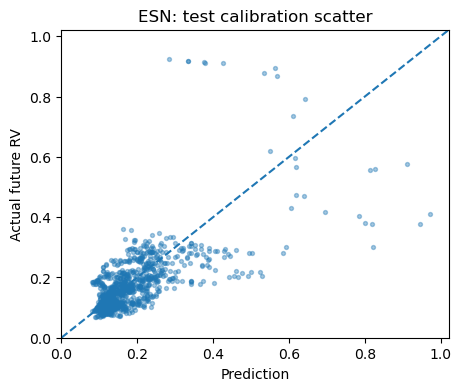

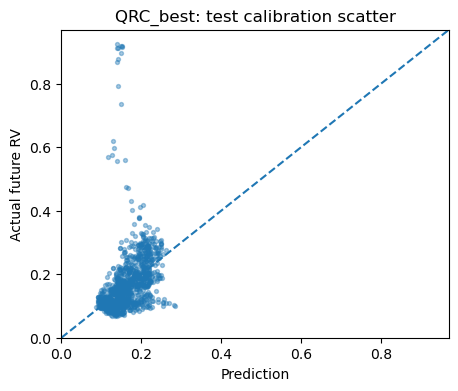

In [10]:
for model, pred in [("ESN", esn_pred_test), ("QRC_best", qrc_pred_test)]:
    plt.figure(figsize=(5, 4))
    plt.scatter(pred, y_test, s=8, alpha=0.4)
    lim = [0, max(float(np.max(y_test)), float(np.max(pred))) * 1.05]
    plt.plot(lim, lim, linestyle="--")
    plt.xlim(lim)
    plt.ylim(lim)
    plt.xlabel("Prediction")
    plt.ylabel("Actual future RV")
    plt.title(f"{model}: test calibration scatter")
    plt.show()

## 9. Save tables

In [11]:
out_dir = Path("results/tables")
out_dir.mkdir(parents=True, exist_ok=True)

comparison.to_csv(out_dir / "phase2_esn_vs_qrc_metric_comparison.csv", index=False)
state_diagnostics.to_csv(out_dir / "phase2_esn_vs_qrc_state_diagnostics.csv", index=False)
high_vol_table.to_csv(out_dir / "phase2_esn_vs_qrc_high_vol_recall.csv", index=False)
error_quantile_table.to_csv(out_dir / "phase2_esn_vs_qrc_error_by_quantile.csv", index=False)

print("Saved ESN-vs-QRC diagnostic tables to", out_dir)

Saved ESN-vs-QRC diagnostic tables to results/tables
